In [1]:
pip install xgboost shap seaborn tensorflow scikit-learn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")


In [3]:
df = pd.read_csv("/content/AnandVihar_Imputed_5Years_Hourly.csv")

df['Time'] = pd.to_datetime(df['Time'], format='%d-%m-%Y %H:%M')
df = df.set_index('Time').sort_index()


In [4]:
df

,AV_PM2.5,AV_PM10,AV_NO,AV_NO2,AV_NOx,AV_NH3,AV_SO2,AV_CO,AV_Ozone,AV_Benzene,AV_Toluene,AT,RH,WS,WD,SR,BP,PP_PM2.5,VV_PM2.5,IG_PM2.5
Time,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,857.50,660.00,146.40,44.90,143.20,89.40,12.08,5.40,67.12,13.78,107.883808,7.50,93.30,0.30,57.75,8.88,986.9,839.75,483.00,763.00
2020-01-01 01:00:00,472.75,623.50,102.08,41.50,105.30,84.22,5.62,2.90,65.32,10.00,92.452186,7.28,94.88,0.30,65.75,8.93,986.9,506.25,456.75,507.25
2020-01-01 02:00:00,384.75,485.75,47.78,40.15,60.32,75.38,0.80,2.18,64.68,6.82,61.322236,7.07,93.88,0.30,68.25,8.85,986.9,371.25,367.75,337.75
2020-01-01 03:00:00,334.50,407.00,124.20,26.95,115.60,55.22,1.75,2.50,63.72,4.80,49.410973,6.85,95.57,0.30,116.00,8.85,986.9,343.00,338.50,352.50
2020-01-01 04:00:00,362.75,464.00,220.85,17.30,216.25,47.97,5.62,3.42,38.42,5.40,47.501995,6.82,97.05,0.30,176.50,8.85,986.9,351.25,342.75,360.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,251.00,373.00,99.48,74.47,120.50,68.55,15.32,3.10,3.00,4.03,42.420000,12.32,79.75,0.50,251.00,5.00,740.0,244.00,232.25,193.75
2024-12-31 20:00:00,306.00,514.00,155.02,70.05,163.35,57.05,17.98,3.23,2.35,5.68,45.500000,11.98,82.25,0.30,251.00,5.00,740.0,250.00,217.00,214.75
2024-12-31 21:00:00,290.00,509.00,126.25,64.50,136.95,66.38,15.48,3.17,1.83,5.85,39.420000,12.15,82.75,0.40,251.00,5.00,740.0,269.00,241.25,206.00


In [5]:
lags = [1, 3, 6, 12, 24]

for lag in lags:
    df[f'AV_lag{lag}'] = df['AV_PM2.5'].shift(lag)
    df[f'PP_lag{lag}'] = df['PP_PM2.5'].shift(lag)
    df[f'VV_lag{lag}'] = df['VV_PM2.5'].shift(lag)
    df[f'IG_lag{lag}'] = df['IG_PM2.5'].shift(lag)


In [6]:
df['WD_sin'] = np.sin(np.deg2rad(df['WD']))
df['WD_cos'] = np.cos(np.deg2rad(df['WD']))

df['hour_sin']  = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos']  = np.cos(2*np.pi*df.index.hour/24)
df['month_sin'] = np.sin(2*np.pi*df.index.month/12)
df['month_cos'] = np.cos(2*np.pi*df.index.month/12)

df.dropna(inplace=True)


In [7]:
def regime(pm):
    if pm < 60:
        return "Low"
    elif pm < 120:
        return "Moderate"
    else:
        return "High"

df['Regime'] = df['AV_PM2.5'].apply(regime)


In [8]:
features = (
    [c for c in df.columns if 'lag' in c] +
    ['AV_PM10','AV_NO','AV_NO2','AV_NOx',
     'AV_CO','AV_SO2','AV_Ozone',
     'AV_NH3','AV_Benzene','AV_Toluene',
     'AT','RH','WS','SR','BP',
     'WD_sin','WD_cos',
     'hour_sin','hour_cos','month_sin','month_cos']
)

target = 'AV_PM2.5'


In [9]:
split = int(0.8 * len(df))
train = df.iloc[:split]
test  = df.iloc[split:]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]


In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)


In [11]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


In [12]:
xgb_global = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_global.fit(X_train, y_train)
pred_xgb = xgb_global.predict(X_test)


In [13]:
models = {}
pred_regime = np.zeros(len(test))

params = dict(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.75,
    objective='reg:squarederror',
    random_state=42
)

for r in train['Regime'].unique():
    tr = train[train['Regime'] == r]
    te = test[test['Regime'] == r]

    model = xgb.XGBRegressor(**params)
    model.fit(tr[features], tr[target])

    models[r] = model
    pred_regime[test['Regime'] == r] = model.predict(te[features])


In [15]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

def make_seq(X, y, lb=24):
    Xs, ys = [], []
    for i in range(len(X)-lb):
        Xs.append(X[i:i+lb])
        ys.append(y.iloc[i+lb])
    return np.array(Xs), np.array(ys)

Xl_tr, yl_tr = make_seq(X_train_s, y_train)
Xl_te, yl_te = make_seq(X_test_s, y_test)

lstm = Sequential([
    LSTM(32, input_shape=(Xl_tr.shape[1], Xl_tr.shape[2])),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(Xl_tr, yl_tr,
          epochs=50,
          batch_size=64,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
          verbose=0)

pred_lstm = lstm.predict(Xl_te).flatten()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
def metrics(y, p):
    return (
        np.sqrt(mean_squared_error(y, p)),
        mean_absolute_error(y, p),
        r2_score(y, p)
    )


In [17]:
results = pd.DataFrame({
    "Model": ["Linear","RF","XGB","Regime-XGB","LSTM"],
    "RMSE": [
        *metrics(y_test, pred_lr)[:1],
        *metrics(y_test, pred_rf)[:1],
        *metrics(y_test, pred_xgb)[:1],
        *metrics(y_test, pred_regime)[:1],
        *metrics(yl_te, pred_lstm)[:1]
    ],
    "MAE": [
        *metrics(y_test, pred_lr)[1:2],
        *metrics(y_test, pred_rf)[1:2],
        *metrics(y_test, pred_xgb)[1:2],
        *metrics(y_test, pred_regime)[1:2],
        *metrics(yl_te, pred_lstm)[1:2]
    ],
    "R2": [
        *metrics(y_test, pred_lr)[2:3],
        *metrics(y_test, pred_rf)[2:3],
        *metrics(y_test, pred_xgb)[2:3],
        *metrics(y_test, pred_regime)[2:3],
        *metrics(yl_te, pred_lstm)[2:3]
    ]
})

print(results)


        Model       RMSE        MAE        R2
0      Linear  30.930519  19.830875  0.930582
1          RF  29.365760  18.723150  0.937428
2         XGB  29.705708  18.937758  0.935971
3  Regime-XGB  24.224180  14.926204  0.957421
4        LSTM  45.245254  29.625291  0.851577


In [18]:
out = pd.DataFrame({
    "Time": test.index,
    "Observed_PM25": y_test,
    "Pred_Regime_XGB": pred_regime
})

out.to_csv("Observed_vs_Predicted_PM25.csv", index=False)


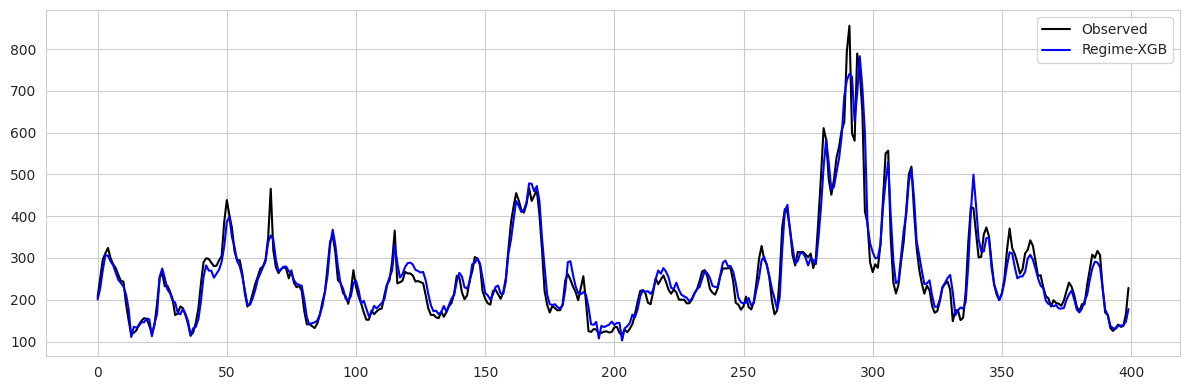

In [19]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:400], label='Observed', color='black')
plt.plot(pred_regime[:400], label='Regime-XGB', color='blue')
plt.legend()
plt.tight_layout()
plt.show()


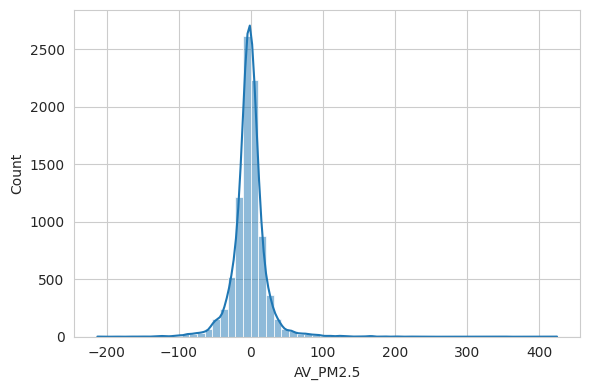

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(y_test - pred_regime, bins=60, kde=True)
plt.tight_layout()
plt.show()


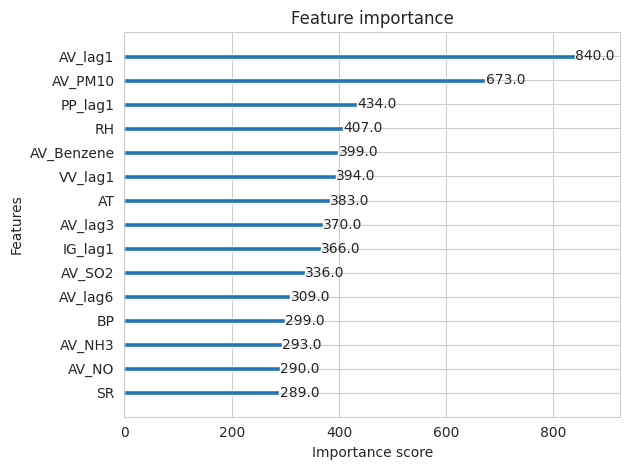

In [21]:
xgb.plot_importance(models['Moderate'], max_num_features=15)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3858048797.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, train[features])


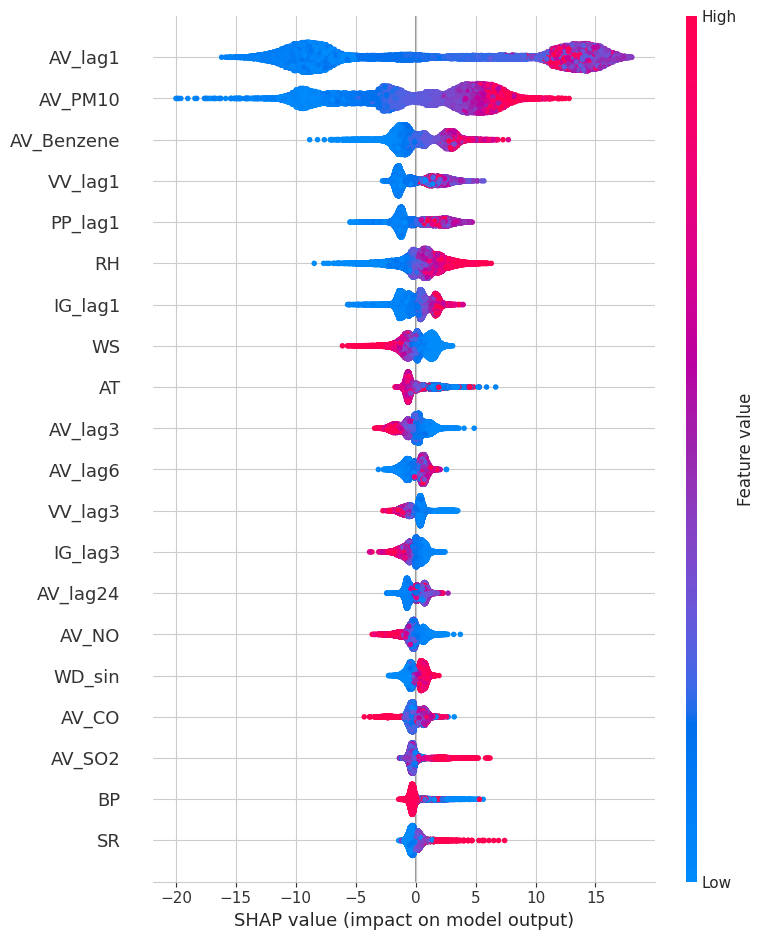

In [22]:
explainer = shap.TreeExplainer(models['Moderate'])
shap_values = explainer.shap_values(train[features])
shap.summary_plot(shap_values, train[features])


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Number of points to display (paper-friendly)
N = 300

# Align LSTM predictions
y_lstm_true = y_test.values[-len(pred_lstm):]

# Common alignment length
N_common = min(
    N,
    len(y_test),
    len(pred_lr),
    len(pred_rf),
    len(pred_xgb),
    len(pred_regime),
    len(pred_lstm)
)

plt.figure(figsize=(14, 5))

# Observed (ground truth)
plt.plot(
    y_test.values[:N_common],
    label="Observed",
    color="black",
    linewidth=2.5
)

# ML baselines
plt.plot(pred_lr[:N_common], label="Linear", alpha=0.7)
plt.plot(pred_rf[:N_common], label="Random Forest", alpha=0.7)
plt.plot(pred_xgb[:N_common], label="XGBoost (Global)", alpha=0.7)

# Proposed model (highlighted)
plt.plot(
    pred_regime[:N_common],
    label="Regime-aware XGBoost (Proposed)",
    linewidth=2.8,
    color="#d62728"
)

# LSTM (aligned from the end)
plt.plot(
    pred_lstm[-N_common:],
    label="LSTM",
    alpha=0.7
)

# Labels and formatting
plt.xlabel("Time (hours)", fontsize=13)
plt.ylabel("PM$_{2.5}$ ($\\mu g/m^3$)", fontsize=13)
plt.title("Observed vs Predicted PM$_{2.5}$ — Model Comparison", fontsize=14)

plt.legend(ncol=3, frameon=False, fontsize=11)
plt.tight_layout()

# Save at high resolution
plt.savefig("Combined_Observed_vs_Predicted_All_Models.png", dpi=500)
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [25]:
# Sample at most 3000 points (safe & representative)
shap_sample = train[train['Regime'] == 'Moderate'][features].sample(
    n=min(3000, len(train)),
    random_state=42
)


In [26]:
explainer = shap.TreeExplainer(models['Moderate'])
shap_values = explainer(shap_sample)


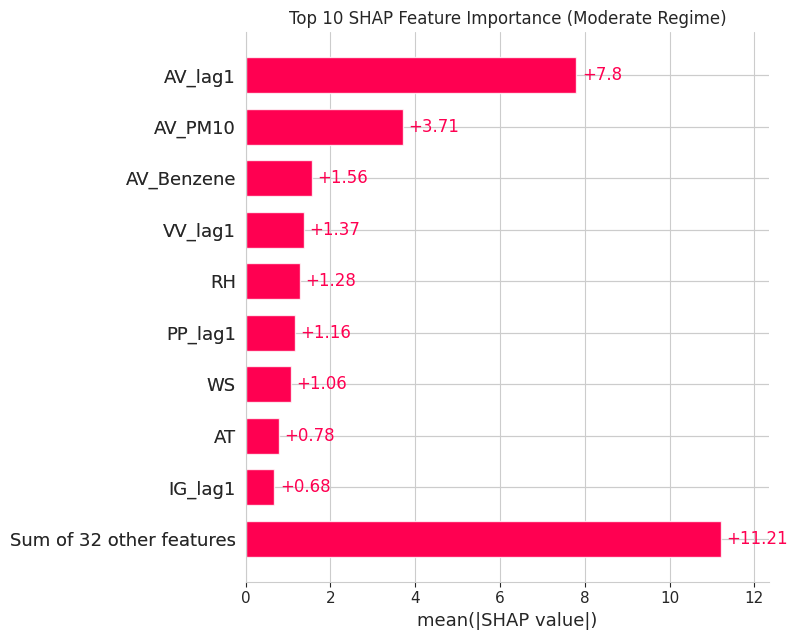

In [28]:
plt.figure(figsize=(6, 4))

shap.plots.bar(
    shap_values,
    max_display=10,   # ← TOP 10 ONLY
    show=False
)

plt.title("Top 10 SHAP Feature Importance (Moderate Regime)", fontsize=12)
plt.tight_layout()
plt.savefig("SHAP_Bar_Moderate_Top10.png", dpi=500)
plt.show()


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def compute_metrics(y_true, y_pred):
    """
    Computes RMSE, MAE, MAPE, and R2 safely.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    r2 = r2_score(y_true, y_pred)

    return rmse, mae, mape, r2


In [30]:
# Align LSTM outputs
y_test_lstm = y_test.values[-len(pred_lstm):]

results = []

results.append(
    ("Linear Regression", *compute_metrics(y_test.values, pred_lr))
)

results.append(
    ("Random Forest", *compute_metrics(y_test.values, pred_rf))
)

results.append(
    ("XGBoost (Global)", *compute_metrics(y_test.values, pred_xgb))
)

results.append(
    ("Regime-aware XGBoost", *compute_metrics(y_test.values, pred_regime))
)

results.append(
    ("LSTM", *compute_metrics(y_test_lstm, pred_lstm))
)


In [31]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "MAPE (%)", "R²"]
)

# Round for publication
results_df[["RMSE", "MAE", "MAPE (%)", "R²"]] = results_df[
    ["RMSE", "MAE", "MAPE (%)", "R²"]
].round(3)

print(results_df)


                  Model    RMSE     MAE  MAPE (%)     R²
0     Linear Regression  30.931  19.831    31.772  0.931
1         Random Forest  29.366  18.723    29.051  0.937
2      XGBoost (Global)  29.706  18.938    30.517  0.936
3  Regime-aware XGBoost  24.224  14.926    22.460  0.957
4                  LSTM  45.245  29.625    47.799  0.852


In [33]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import xgboost as xgb


In [34]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2


In [35]:
def assign_regime(pm):
    if pm < 60:
        return "Low"
    elif pm < 120:
        return "Moderate"
    else:
        return "High"


In [36]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

xgb_params = dict(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.75,
    colsample_bytree=0.75,
    objective="reg:squarederror",
    random_state=42
)

fold = 1

for train_idx, test_idx in tscv.split(df):

    train = df.iloc[train_idx].copy()
    test  = df.iloc[test_idx].copy()

    # Assign regimes INSIDE fold (CRITICAL)
    train["Regime"] = train["AV_PM2.5"].apply(assign_regime)
    test["Regime"]  = test["AV_PM2.5"].apply(assign_regime)

    y_test = test["AV_PM2.5"].values
    pred_fold = np.zeros(len(test))

    # Train regime-specific models
    for regime in train["Regime"].unique():

        train_r = train[train["Regime"] == regime]
        test_r  = test[test["Regime"] == regime]

        if len(train_r) < 100:
            continue  # safety

        model = xgb.XGBRegressor(**xgb_params)
        model.fit(train_r[features], train_r["AV_PM2.5"])

        pred_fold[test["Regime"] == regime] = model.predict(test_r[features])

    # Evaluate fold
    rmse, mae, mape, r2 = compute_metrics(y_test, pred_fold)

    cv_results.append([fold, rmse, mae, mape, r2])
    print(f"Fold {fold}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%, R²={r2:.3f}")

    fold += 1


Fold 1: RMSE=35.62, MAE=16.45, MAPE=13.39%, R²=0.916
Fold 2: RMSE=28.13, MAE=16.48, MAPE=17.32%, R²=0.944
Fold 3: RMSE=22.42, MAE=12.88, MAPE=16.24%, R²=0.956
Fold 4: RMSE=25.21, MAE=14.18, MAPE=19.12%, R²=0.954
Fold 5: RMSE=23.98, MAE=14.48, MAPE=24.46%, R²=0.957


In [37]:
cv_df = pd.DataFrame(
    cv_results,
    columns=["Fold", "RMSE", "MAE", "MAPE (%)", "R²"]
)

print("\n5-Fold Cross-Validation Results:")
print(cv_df.round(3))

print("\nMean ± Std (Cross-Validation):")
print(cv_df[["RMSE", "MAE", "MAPE (%)", "R²"]].agg(["mean", "std"]).round(3))



5-Fold Cross-Validation Results:
   Fold    RMSE     MAE  MAPE (%)     R²
0     1  35.623  16.448    13.387  0.916
1     2  28.129  16.477    17.322  0.944
2     3  22.421  12.881    16.243  0.956
3     4  25.208  14.182    19.122  0.954
4     5  23.980  14.481    24.455  0.957

Mean ± Std (Cross-Validation):
        RMSE     MAE  MAPE (%)     R²
mean  27.072  14.894    18.106  0.945
std    5.218   1.553     4.114  0.017


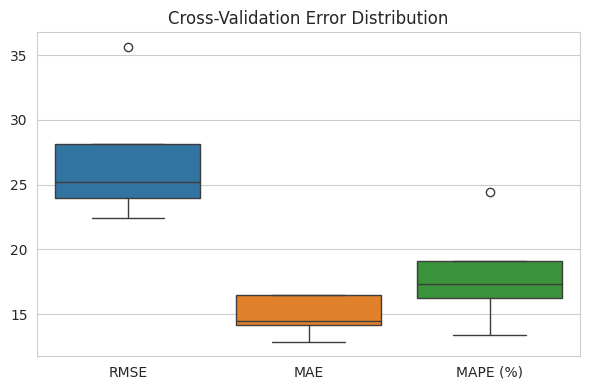

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=cv_df[['RMSE','MAE','MAPE (%)']])
plt.title("Cross-Validation Error Distribution")
plt.tight_layout()
plt.savefig("CV_Boxplot.png", dpi=500)
plt.show()


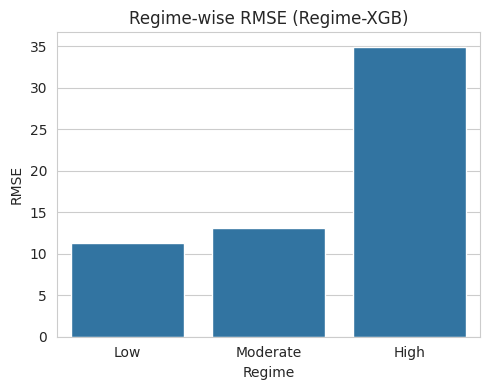

In [39]:
regime_metrics = pd.DataFrame({
    "Regime": ["Low","Moderate","High"],
    "RMSE": [11.26, 13.09, 34.93]
})

plt.figure(figsize=(5,4))
sns.barplot(x="Regime", y="RMSE", data=regime_metrics)
plt.title("Regime-wise RMSE (Regime-XGB)")
plt.tight_layout()
plt.savefig("Regime_RMSE.png", dpi=500)
plt.show()
